# Methods Comparsion SAMSON- Unmix Paper

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from scipy.io import loadmat
import h5py
import scipy.io

C:\Users\User\miniconda3\envs\spill\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## NMF-QMV

In [2]:
# adjust path if needed
data_nmfqmv = loadmat('Data/Methods_Comparison/Samson/abundance_maps_SAMSON_NMF_QMV.mat')

# extract your array
abundance_maps_nmfqmv = data_nmfqmv['abundance_maps']  
# abundance_maps.shape will be (p, 256, 256)
order = [0,2,1]  
abundance_maps_nmfqmv = abundance_maps_nmfqmv[order, :, :]
p_nmfqmv = abundance_maps_nmfqmv.shape[0]


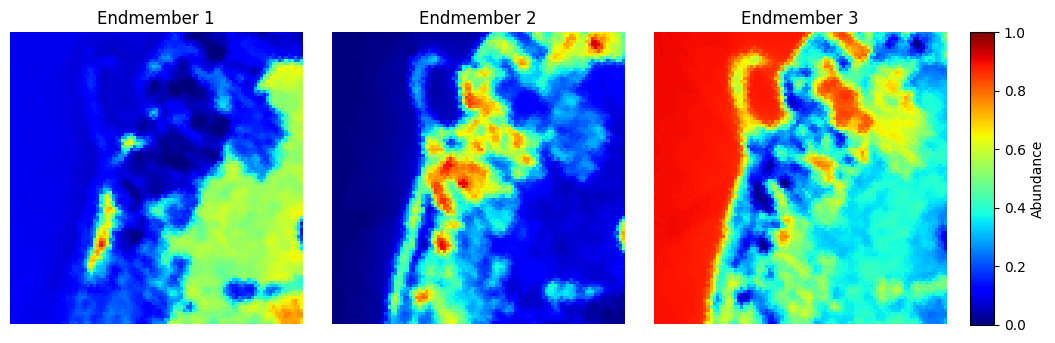

In [3]:
# Create subplots
fig, axes = plt.subplots(1, p_nmfqmv, figsize=(4*p_nmfqmv, 4))

for i, ax in enumerate(axes):
    im = ax.imshow(abundance_maps_nmfqmv[i], cmap='jet', vmin=0, vmax=1)
    ax.set_title(f'Endmember {i+1}')
    ax.axis('off')

# Shrink the right side of the subplots to make room for the colorbar
fig.subplots_adjust(left=0.02, right=0.8, wspace=0.1)

# Get position of the last axis
pos = axes[-1].get_position()

# Place a colorbar exactly matching its height
cax = fig.add_axes([pos.x1 + 0.02, pos.y0, 0.02, pos.height])
fig.colorbar(im, cax=cax, label='Abundance')

plt.show()

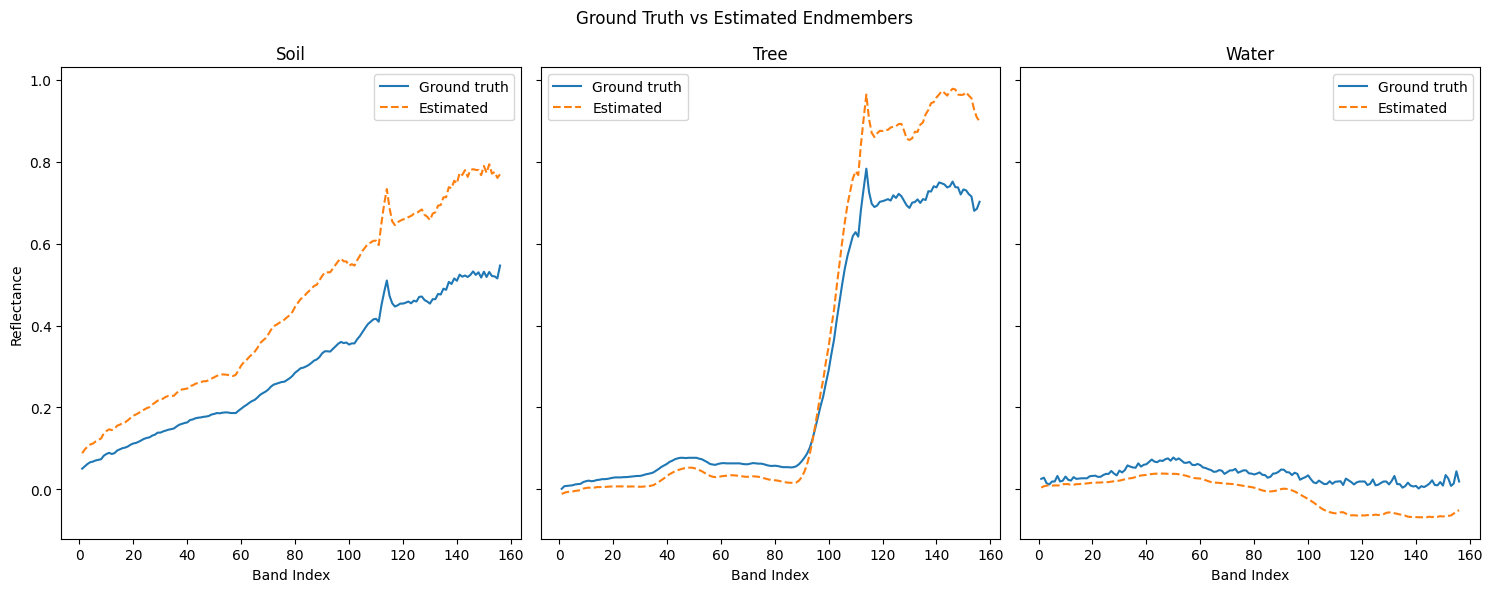

In [4]:
# 1) Load ground truth spectra
gt_data = scipy.io.loadmat('Data/Methods_Comparison/Samson/spectra.mat')
specs    = gt_data['specs']             # shape: (bands, endmembers)
wvl      = gt_data['wvl'].flatten()     # shape: (bands,)
labels   = [lbl[0] for lbl in gt_data['labels'][0]]  # ['Vegetation', 'Manmade', 'Soil']

# 2) Load estimated endmembers
est_data = scipy.io.loadmat('Data/Methods_Comparison/Samson/endmembers_SAMSON_NMF_QMV.mat')
A_output_nmfqmv = est_data['A_output']         # maybe shape: (bands, endmembers) or (1, bands, endmembers)
order     = [0, 2, 1]        # new column order
A_output_nmfqmv = A_output_nmfqmv[:, order]

# 3) Define your new labels
labels = ['Soil', 'Tree', 'Water']

# 3) Plot ground truth vs estimated
bands, n_end = specs.shape
fig, axes  = plt.subplots(1, n_end, figsize=(5*n_end, 6), sharex=True, sharey=True)

for i in range(n_end):
    ax = axes[i]
    ax.plot(wvl, specs[:, i], label='Ground truth')
    ax.plot(wvl, A_output_nmfqmv[:, i], label='Estimated', linestyle='--')
    ax.set_title(labels[i] if i < len(labels) else f'Endmember {i+1}')
    ax.set_xlabel('Band Index')
    if i == 0:
        ax.set_ylabel('Reflectance')
    ax.legend()

plt.suptitle('Ground Truth vs Estimated Endmembers')
plt.tight_layout()
plt.show()


## MLNMF

In [5]:
# adjust path if needed
data_mlnmf = loadmat('Data/Methods_Comparison/Samson/AbundanceMaps_SAMSON_MLNMF.mat')

# extract your array
abundance_maps_mlnmf = data_mlnmf['AbundanceMaps']  
# abundance_maps.shape will be (p, 256, 256)
abundance_maps_mlnmf = abundance_maps_mlnmf.transpose(2,0,1)

# Permute endmember order along axis 0:
order = [2,0,1]  
abundance_maps_mlnmf = abundance_maps_mlnmf[order, :, :]

p_mlnmf = abundance_maps_mlnmf.shape[0]

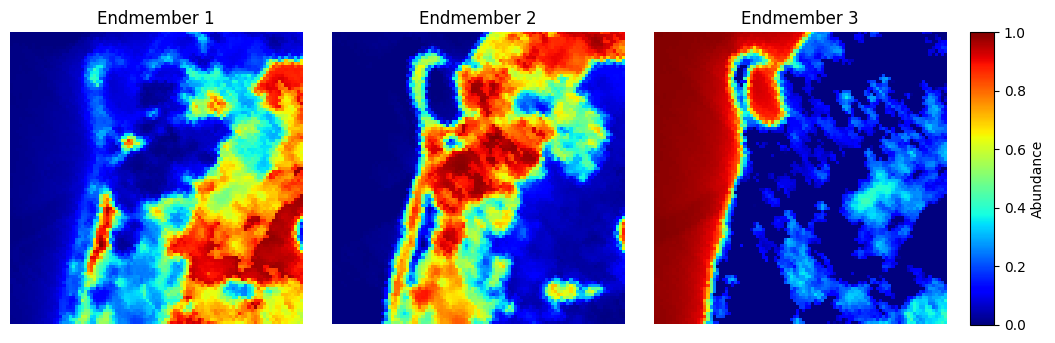

In [6]:
# Create subplots
fig, axes = plt.subplots(1, p_mlnmf, figsize=(4*p_mlnmf, 4))

for i, ax in enumerate(axes):
    im = ax.imshow(abundance_maps_mlnmf[i], cmap='jet', vmin=0, vmax=1)
    ax.set_title(f'Endmember {i+1}')
    ax.axis('off')

# Shrink the right side of the subplots to make room for the colorbar
fig.subplots_adjust(left=0.02, right=0.8, wspace=0.1)

# Get position of the last axis
pos = axes[-1].get_position()

# Place a colorbar exactly matching its height
cax = fig.add_axes([pos.x1 + 0.02, pos.y0, 0.02, pos.height])
fig.colorbar(im, cax=cax, label='Abundance')

plt.show()

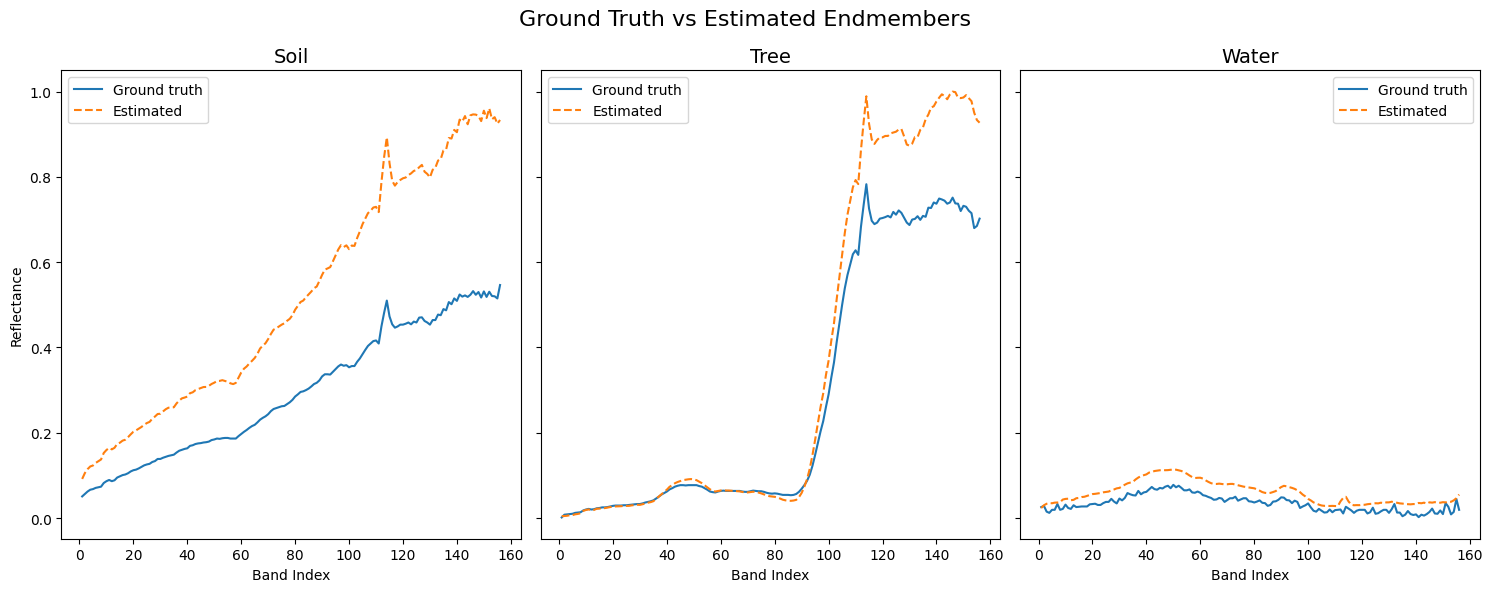

In [7]:
# 2) Load estimated endmembers
est_data = scipy.io.loadmat('Data/Methods_Comparison/Samson/endmembers_SAMSON_MLNMF.mat')
A_output_mlnmf = est_data['A_ml']         # e.g. (bands, 3) or (1, bands, 3)
wvl         = est_data['wavelengths'].flatten()

# permute the *columns* in the order (0,2,1)
order     = [2,0,1]
A_output_mlnmf  = A_output_mlnmf[:, order]
# global max normalization
max_val = A_output_mlnmf.max()
A_output_mlnmf = A_output_mlnmf / max_val

# optional: names for the estimated classes (if you want to refer to them)
est_labels = ['Soil','Tree','Water']

# 3) Plot side-by-side, keeping GT order in the titles
bands, n_end = specs.shape
fig, axes   = plt.subplots(1, n_end, figsize=(5*n_end, 6), sharex=True, sharey=True)

for i in range(n_end):
    ax = axes[i]
    ax.plot(wvl, specs[:, i],    label='Ground truth')
    ax.plot(wvl, A_output_mlnmf[:, i], label='Estimated', linestyle='--')
    ax.set_title(est_labels[i], fontsize=14)
    ax.set_xlabel('Band Index')
    if i == 0:
        ax.set_ylabel('Reflectance')
    ax.legend()

plt.suptitle('Ground Truth vs Estimated Endmembers', fontsize=16)
plt.tight_layout()
plt.show()

## FCLS + VCA

In [8]:
# adjust path if needed
data_fcls = loadmat('Data/Methods_Comparison/Samson/FCLSU_Abundance_SAMSON.mat')

# extract your array
abundance_maps_fcls = data_fcls['abundance_maps']  
# abundance_maps.shape will be (p, 256, 256)
abundance_maps_fcls = abundance_maps_fcls.transpose(2,0,1)

# Permute endmember order along axis 0: 
order = [1,2,0]
abundance_maps_fcls = abundance_maps_fcls[order, :, :]

p_fcls = abundance_maps_fcls.shape[0]

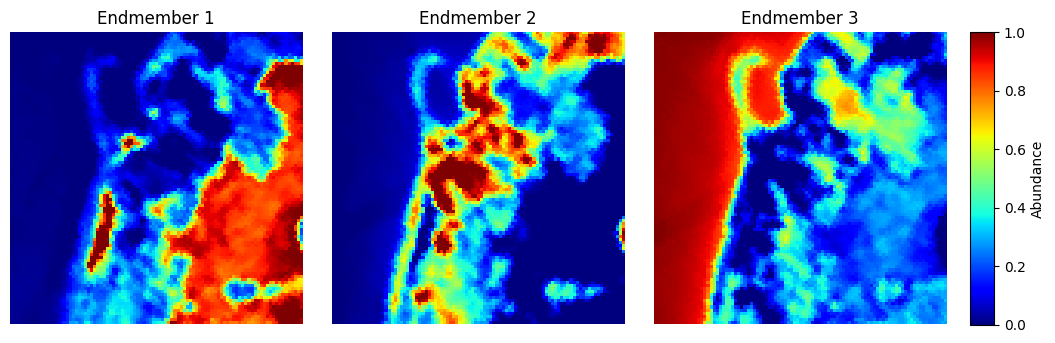

In [9]:
# Create subplots
fig, axes = plt.subplots(1, p_fcls, figsize=(4*p_fcls, 4))

for i, ax in enumerate(axes):
    im = ax.imshow(abundance_maps_fcls[i], cmap='jet', vmin=0, vmax=1)
    ax.set_title(f'Endmember {i+1}')
    ax.axis('off')

# Shrink the right side of the subplots to make room for the colorbar
fig.subplots_adjust(left=0.02, right=0.8, wspace=0.1)

# Get position of the last axis
pos = axes[-1].get_position()

# Place a colorbar exactly matching its height
cax = fig.add_axes([pos.x1 + 0.02, pos.y0, 0.02, pos.height])
fig.colorbar(im, cax=cax, label='Abundance')

plt.show()

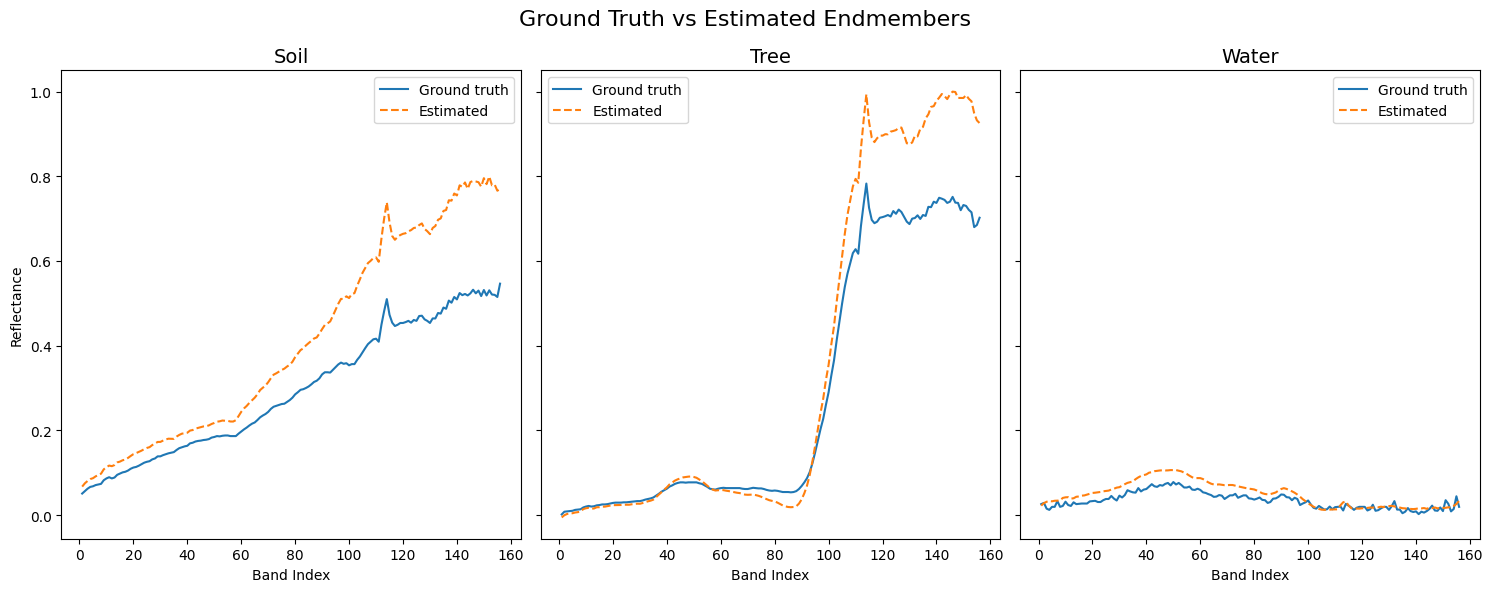

In [10]:
# 2) Load estimated endmembers
est_data = scipy.io.loadmat('Data/Methods_Comparison/Samson/endmembers_SAMSON_FCLSU.mat')
A_output_fclsu = est_data['M']         # e.g. (bands, 3) or (1, bands, 3)

# permute the *columns* in the order (0,2,1)
order     = [1,2,0]
A_output_fclsu  = A_output_fclsu[:, order]
# global max normalization
max_val = A_output_fclsu.max()
A_output_fclsu = A_output_fclsu / max_val

# optional: names for the estimated classes (if you want to refer to them)
est_labels = ['Soil','Tree','Water']

# 3) Plot side-by-side, keeping GT order in the titles
bands, n_end = specs.shape
fig, axes   = plt.subplots(1, n_end, figsize=(5*n_end, 6), sharex=True, sharey=True)

for i in range(n_end):
    ax = axes[i]
    ax.plot(wvl, specs[:, i],    label='Ground truth')
    ax.plot(wvl, A_output_fclsu[:, i], label='Estimated', linestyle='--')
    ax.set_title(est_labels[i], fontsize=14)
    ax.set_xlabel('Band Index')
    if i == 0:
        ax.set_ylabel('Reflectance')
    ax.legend()

plt.suptitle('Ground Truth vs Estimated Endmembers', fontsize=16)
plt.tight_layout()
plt.show()

## CyCU

In [11]:
# adjust path if needed
data_cycu = loadmat('Data/Methods_Comparison/Samson/samson_cycunet_result.mat')

# extract your array
abundance_maps_cycu = data_cycu['abu_est']  
# abundance_maps.shape will be (p, 256, 256)
abundance_maps_cycu = abundance_maps_cycu.transpose(0,2,1)

# Permute endmember order along axis 0: 
order = [2,0,1]
abundance_maps_cycu = abundance_maps_cycu[order, :, :]

p_fcls = abundance_maps_cycu.shape[0]

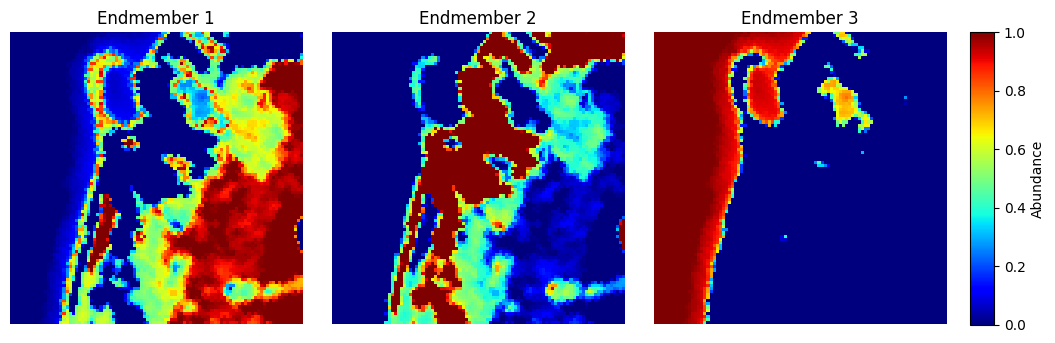

In [12]:
# Create subplots
fig, axes = plt.subplots(1, p_fcls, figsize=(4*p_fcls, 4))

for i, ax in enumerate(axes):
    im = ax.imshow(abundance_maps_cycu[i], cmap='jet', vmin=0, vmax=1)
    ax.set_title(f'Endmember {i+1}')
    ax.axis('off')

# Shrink the right side of the subplots to make room for the colorbar
fig.subplots_adjust(left=0.02, right=0.8, wspace=0.1)

# Get position of the last axis
pos = axes[-1].get_position()

# Place a colorbar exactly matching its height
cax = fig.add_axes([pos.x1 + 0.02, pos.y0, 0.02, pos.height])
fig.colorbar(im, cax=cax, label='Abundance')

plt.show()

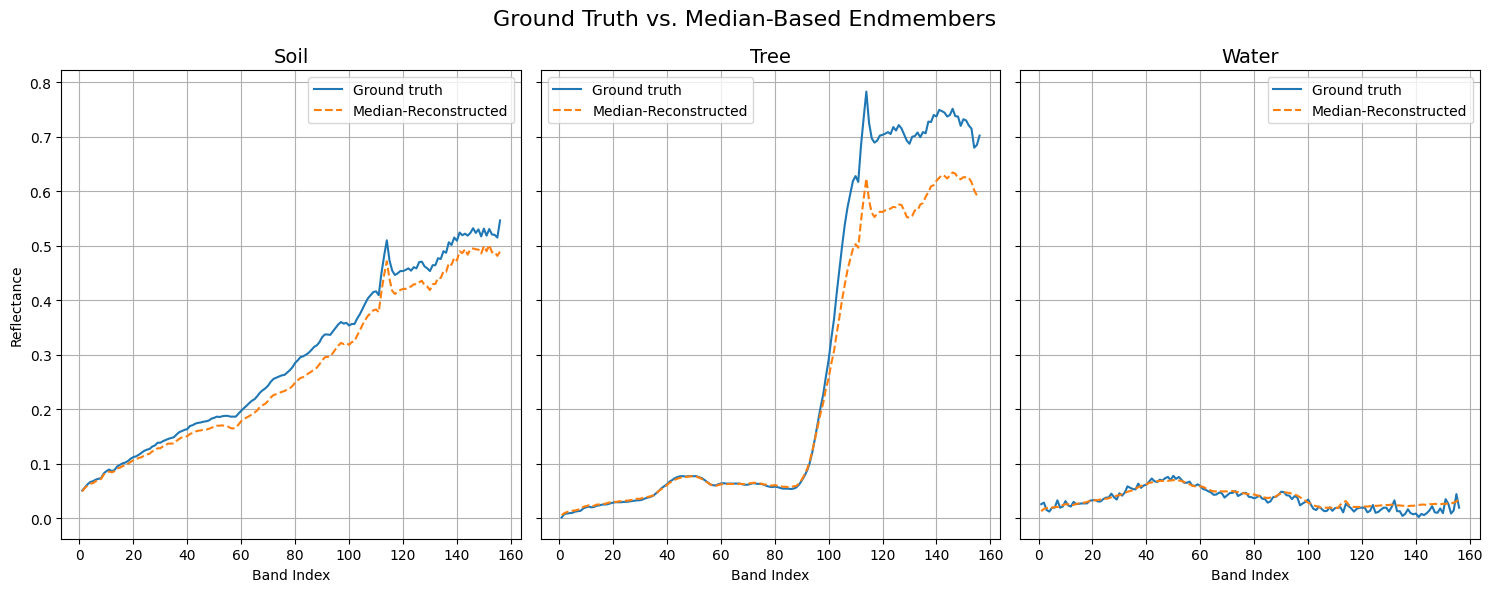

In [13]:
Y        = data_cycu['Y']        # shape: (bands, H, W)
abu_est  = data_cycu['abu_est']  # shape: (E,     H, W)

bands, H, W = Y.shape
E = abu_est.shape[0]

# 2) Compute median spectra for pixels where abundance > 0.9
rec_specs = np.zeros((bands, E), dtype=np.float64)
for e in range(E):
    mask = (abu_est[e] > 0.9)         # [H,W] Boolean
    if mask.sum() > 0:
        # collect all spectra Y[:,mask] → shape (bands, n_sel)
        rec_specs[:, e] = np.median(Y[:, mask], axis=1)
    else:
        rec_specs[:, e] = 0.0

# 3) Now you can pretend rec_specs is your “estimated” M:
A_output_cycu = rec_specs

# optional: if needed, permute columns
order = [2,0,1]
A_output_cycu = A_output_cycu[:, order]

# 4) Plot side-by-side, keeping GT order in the titles
est_labels = ['Soil','Tree','Water']
n_end = specs.shape[1]

fig, axes = plt.subplots(1, n_end, figsize=(5*n_end, 6), sharex=True, sharey=True)
for i in range(n_end):
    ax = axes[i]
    ax.plot(wvl, specs[:, i],          label='Ground truth', color='C0')
    ax.plot(wvl, A_output_cycu[:, i],   label='Median‐Reconstructed', 
            linestyle='--', color='C1')
    ax.set_title(est_labels[i], fontsize=14)
    ax.set_xlabel('Band Index')
    if i == 0:
        ax.set_ylabel('Reflectance')
    ax.legend()
    ax.grid(True)

plt.suptitle('Ground Truth vs. Median‐Based Endmembers', fontsize=16)
plt.tight_layout()
plt.show()

## DeepTrans

In [14]:
# adjust path if needed
data_dt = loadmat('Data/Methods_Comparison/Samson/Abundance_Samson_DeepTRans.mat')

# extract your array
abundance_maps_dt = data_dt['a_Tra']  
# abundance_maps.shape will be (p, 256, 256)
abundance_maps_dt = abundance_maps_dt.transpose(2,0,1)

# Permute endmember order along axis 0: 
# order = [2,0,1]
# abundance_maps_dt = abundance_maps_dt[order, :, :]

p_dt = abundance_maps_dt.shape[0]

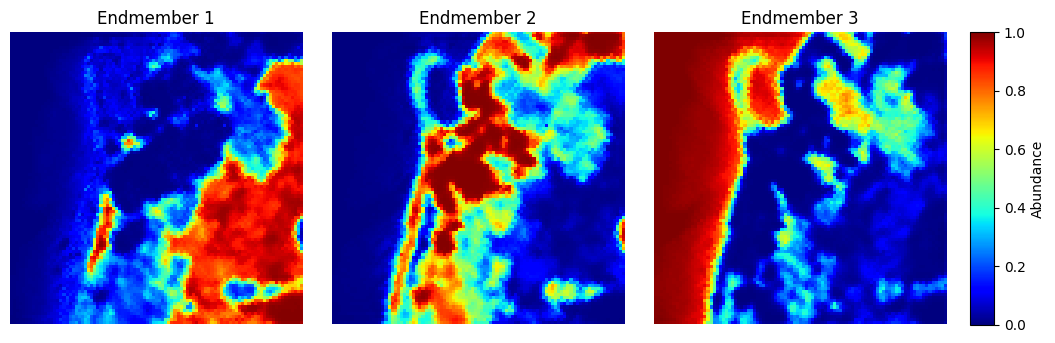

In [15]:
# Create subplots
fig, axes = plt.subplots(1, p_dt, figsize=(4*p_dt, 4))

for i, ax in enumerate(axes):
    im = ax.imshow(abundance_maps_dt[i], cmap='jet', vmin=0, vmax=1)
    ax.set_title(f'Endmember {i+1}')
    ax.axis('off')

# Shrink the right side of the subplots to make room for the colorbar
fig.subplots_adjust(left=0.02, right=0.8, wspace=0.1)

# Get position of the last axis
pos = axes[-1].get_position()

# Place a colorbar exactly matching its height
cax = fig.add_axes([pos.x1 + 0.02, pos.y0, 0.02, pos.height])
fig.colorbar(im, cax=cax, label='Abundance')

plt.show()

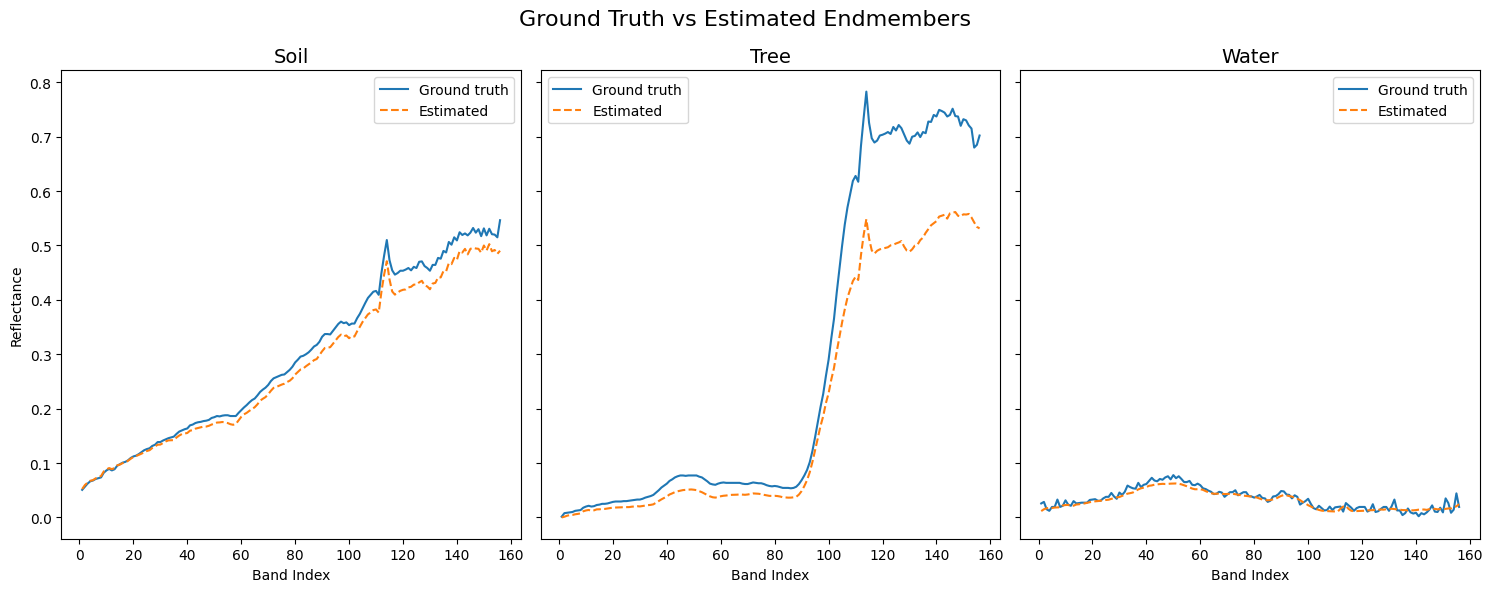

In [16]:
# 2) Load estimated endmembers
est_data = scipy.io.loadmat('Data/Methods_Comparison/Samson/Endmembers_Samson_DeepTrans.mat')
A_output_dt = est_data['E_Tra']         # e.g. (bands, 3) or (1, bands, 3)

# permute the *columns* in the order (0,2,1)
# order     = [1,2,0]
# A_output_dt  = A_output_dt[:, order]
# global max normalization
# max_val = A_output_dt.max()
# A_output_dt = A_output_dt / max_val

# optional: names for the estimated classes (if you want to refer to them)
est_labels = ['Soil','Tree','Water']

# 3) Plot side-by-side, keeping GT order in the titles
bands, n_end = specs.shape
fig, axes   = plt.subplots(1, n_end, figsize=(5*n_end, 6), sharex=True, sharey=True)

for i in range(n_end):
    ax = axes[i]
    ax.plot(wvl, specs[:, i],    label='Ground truth')
    ax.plot(wvl, A_output_dt[:, i], label='Estimated', linestyle='--')
    ax.set_title(est_labels[i], fontsize=14)
    ax.set_xlabel('Band Index')
    if i == 0:
        ax.set_ylabel('Reflectance')
    ax.legend()

plt.suptitle('Ground Truth vs Estimated Endmembers', fontsize=16)
plt.tight_layout()
plt.show()

## UST-Net

In [17]:
# adjust path if needed
data_ust = loadmat('Data/Methods_Comparison/Samson/Samson_result_UST_NET.mat')

# extract your array
abundance_maps_ust = data_ust['S']  
# abundance_maps.shape will be (p, 256, 256)
abundance_maps_ust = abundance_maps_ust.transpose(2,1,0)

# Permute endmember order along axis 0: 
# order = [2,0,1]
# abundance_maps_dt = abundance_maps_dt[order, :, :]

p_ust = abundance_maps_ust.shape[0]

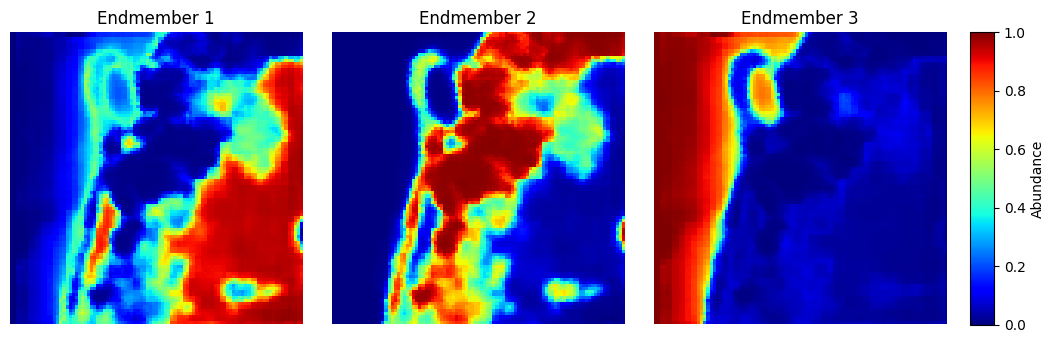

In [18]:
# Create subplots
fig, axes = plt.subplots(1, p_ust, figsize=(4*p_ust, 4))

for i, ax in enumerate(axes):
    im = ax.imshow(abundance_maps_ust[i], cmap='jet', vmin=0, vmax=1)
    ax.set_title(f'Endmember {i+1}')
    ax.axis('off')

# Shrink the right side of the subplots to make room for the colorbar
fig.subplots_adjust(left=0.02, right=0.8, wspace=0.1)

# Get position of the last axis
pos = axes[-1].get_position()

# Place a colorbar exactly matching its height
cax = fig.add_axes([pos.x1 + 0.02, pos.y0, 0.02, pos.height])
fig.colorbar(im, cax=cax, label='Abundance')

plt.show()

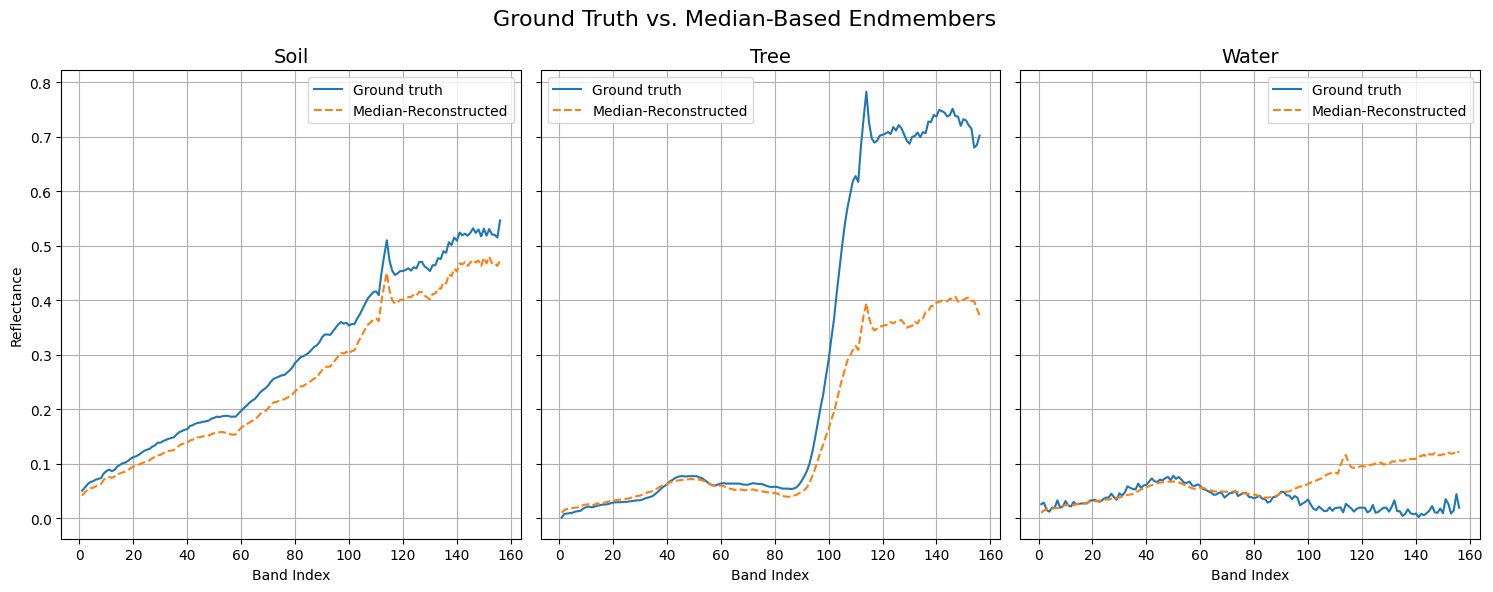

In [19]:
Y        = data_cycu['Y']        # shape: (bands, H, W)
abu_est  = data_ust['S'].transpose(2,1,0)  # shape: (E,     H, W)

bands, H, W = Y.shape
E = abu_est.shape[0]

# 2) Compute median spectra for pixels where abundance > 0.9
rec_specs = np.zeros((bands, E), dtype=np.float64)
for e in range(E):
    mask = (abu_est[e] > 0.9)         # [H,W] Boolean
    if mask.sum() > 0:
        # collect all spectra Y[:,mask] → shape (bands, n_sel)
        rec_specs[:, e] = np.median(Y[:, mask], axis=1)
    else:
        rec_specs[:, e] = 0.0

# 3) Now you can pretend rec_specs is your “estimated” M:
A_output_ust = rec_specs

# optional: if needed, permute columns
# order = [2,0,1]
# A_output_cycu = A_output_cycu[:, order]

# 4) Plot side-by-side, keeping GT order in the titles
est_labels = ['Soil','Tree','Water']
n_end = specs.shape[1]

fig, axes = plt.subplots(1, n_end, figsize=(5*n_end, 6), sharex=True, sharey=True)
for i in range(n_end):
    ax = axes[i]
    ax.plot(wvl, specs[:, i],          label='Ground truth', color='C0')
    ax.plot(wvl, A_output_ust[:, i],   label='Median‐Reconstructed', 
            linestyle='--', color='C1')
    ax.set_title(est_labels[i], fontsize=14)
    ax.set_xlabel('Band Index')
    if i == 0:
        ax.set_ylabel('Reflectance')
    ax.legend()
    ax.grid(True)

plt.suptitle('Ground Truth vs. Median‐Based Endmembers', fontsize=16)
plt.tight_layout()
plt.show()

## ViT - Ours

In [20]:
abundance_maps_vit = np.load('Data/Methods_Comparison/Samson\ViT_samson_abundances_b08_P5.npy')
abundance_maps_vit.shape

(3, 95, 95)

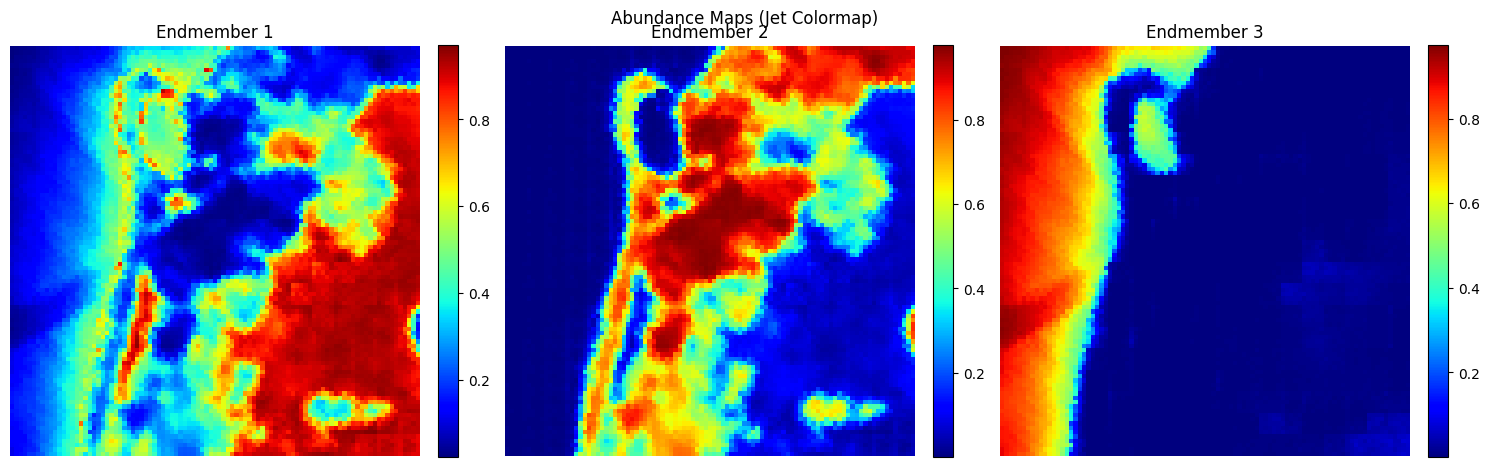

In [21]:
n_maps = abundance_maps_vit.shape[0]
fig, axes = plt.subplots(1, n_maps, figsize=(5 * n_maps, 5))

for i in range(n_maps):
    im = axes[i].imshow(abundance_maps_vit[i], cmap='jet')
    axes[i].set_title(f'Endmember {i+1}')
    axes[i].axis('off')
    # add individual colorbars
    fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

plt.suptitle('Abundance Maps (Jet Colormap)', y=0.95)
plt.tight_layout()
plt.show()

(156, 3) (156, 3)


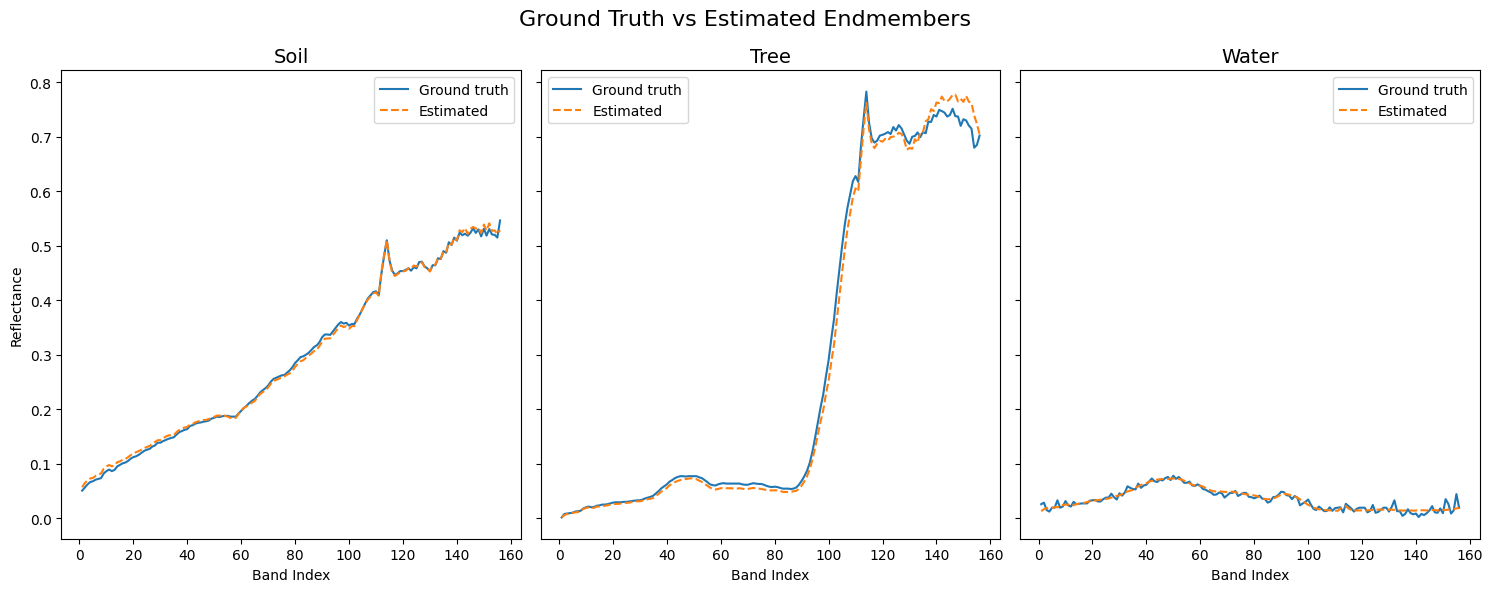

In [22]:
# 2) Load estimated endmembers
est_data = np.load('Data/Methods_Comparison/Samson/ViT_Endmembers_SAMSON_b08_P5.npy')
A_output_vit = est_data         # e.g. (bands, 3) or (1, bands, 3)

specs1=specs.transpose(1,0)

norms_gt = np.linalg.norm(specs1, axis=1)  # (E,)
A_output_vit = A_output_vit * norms_gt[:, None]  # [E, bands]


A_output_vit = A_output_vit.transpose(1,0)
print(A_output_vit.shape,specs.shape)
# permute the *columns* in the order (0,2,1)
# order     = [1,2,0]
# A_output_vit  = A_output_vit[order, :]
# global max normalization
# max_val = A_output_vit.max()
# A_output_vit = A_output_vit / max_val

# optional: names for the estimated classes (if you want to refer to them)
est_labels = ['Soil','Tree','Water']

# 3) Plot side-by-side, keeping GT order in the titles
bands, n_end = specs.shape
fig, axes   = plt.subplots(1, n_end, figsize=(5*n_end, 6), sharex=True, sharey=True)

for i in range(n_end):
    ax = axes[i]
    ax.plot(wvl, specs[:, i],    label='Ground truth')
    ax.plot(wvl, A_output_vit[:, i], label='Estimated', linestyle='--')
    ax.set_title(est_labels[i], fontsize=14)
    ax.set_xlabel('Band Index')
    if i == 0:
        ax.set_ylabel('Reflectance')
    ax.legend()

plt.suptitle('Ground Truth vs Estimated Endmembers', fontsize=16)
plt.tight_layout()
plt.show()

## GT

Loaded maps shape: (95, 95, 3)


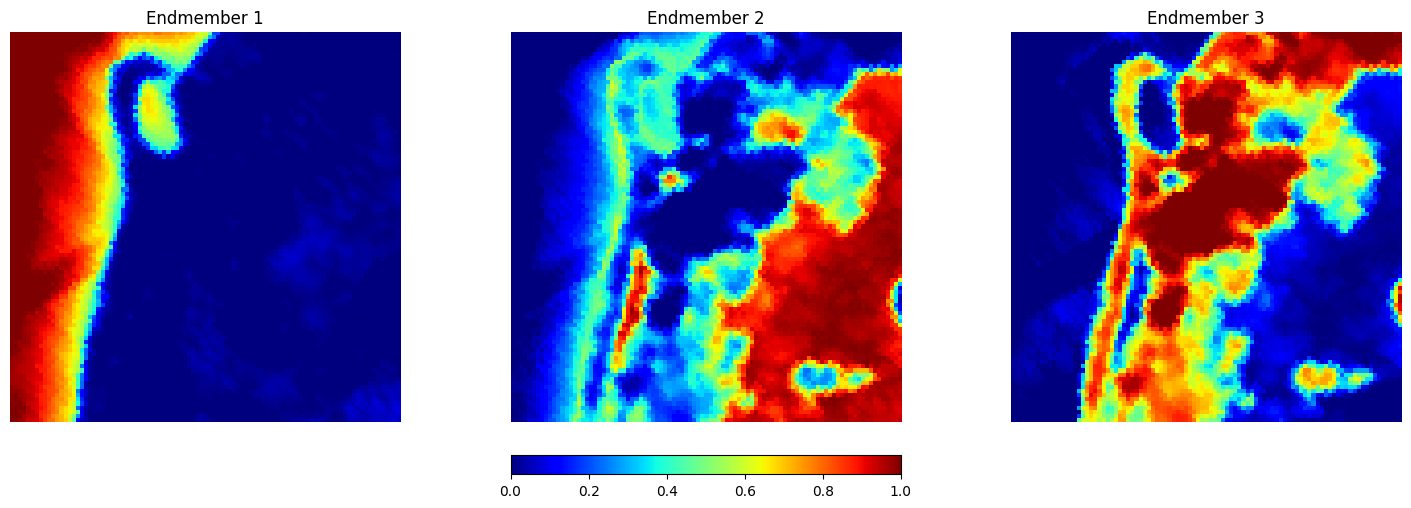

In [23]:
# load
data = scipy.io.loadmat('D:\CS300\Project\Transformer\SAMSON\end3_Abundances_CData.mat')
maps = data['maps']    # shape: (rows, cols, 3)

# quick check
print("Loaded maps shape:", maps.shape)

# plot
fig, axes = plt.subplots(1, maps.shape[2], figsize=(15,5), constrained_layout=True)
for i in range(maps.shape[2]):
    im = axes[i].imshow(maps[:,:,i], cmap='jet')
    axes[i].set_title(f'Endmember {i+1}')
    axes[i].axis('off')
fig.colorbar(im, ax=axes, orientation='horizontal', fraction=0.05, pad=0.08)
plt.show()


In [24]:
maps_GT = maps.transpose(2,0,1)    # shape: (rows, cols, 3)
order     = [1,2,0]
maps_GT  = maps_GT[order,: ,:]

## RMSE

In [25]:
methods = {
    'GT':             maps_GT,
    'MLNMF':          abundance_maps_mlnmf,
    'NMF-QMV':        abundance_maps_nmfqmv,
    'FCLSU + VCA':    abundance_maps_fcls,
    'CyCU':  abundance_maps_cycu,
    'DeepTrans':  abundance_maps_dt,
    'UST-Net':  abundance_maps_ust,
    'ViT - Proposed': abundance_maps_vit
}

In [26]:
rmse_results = {}

for name, maps in methods.items():
    if name == 'GT': 
        continue
    
    # compute per‐endmember RMSE
    per_map = []
    for e in range(maps_GT.shape[0]):
        gt_e  = maps_GT[e].ravel()
        est_e = maps[e].ravel()
        per_map.append( np.sqrt(mean_squared_error(gt_e, est_e)) )
    
    rmse_results[name] = per_map

# print them all
for name, per_map in rmse_results.items():
    print(f"{name:12s} → RMSE per endmember: {per_map}")

MLNMF        → RMSE per endmember: [0.1381916856789908, 0.08385728066389393, 0.17016803045984913]
NMF-QMV      → RMSE per endmember: [0.24734563838539636, 0.25527173856978996, 0.38797697804264364]
FCLSU + VCA  → RMSE per endmember: [0.17810355424172053, 0.20160134277505243, 0.2742461294068535]
CyCU         → RMSE per endmember: [0.18313622854598174, 0.1908767757140263, 0.1563127435237887]
DeepTrans    → RMSE per endmember: [0.14840878125886733, 0.12609443407811607, 0.23354544563257607]
UST-Net      → RMSE per endmember: [0.06649084892574371, 0.06431437428243715, 0.06264621294495999]
ViT - Proposed → RMSE per endmember: [0.09086502579793408, 0.06341476693122293, 0.058093298582872245]


## SAD

In [27]:
methods_specs = {
    'GT':             specs.T,
    'MLNMF':          A_output_mlnmf.T,
    'NMF-QMV':        A_output_nmfqmv.T,
    'FCLSU + VCA':    A_output_fclsu.T,
    'CyCU':  A_output_cycu.T,
    'DeepTrans':  A_output_dt.T,
    'UST-Net':  A_output_ust.T,
    'ViT - Proposed': A_output_vit.T
}

In [28]:
def spectral_angle(a, b):
    """Returns SAD in radians between two 1D arrays."""
    cos = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12)
    cos = np.clip(cos, -1, 1)
    return np.arccos(cos)

# methods_specs[name] is shape (3, bands), and 'GT' is the ground truth
sad_results = {}

for name, arr in methods_specs.items():
    if name == 'GT':
        continue
    gt = methods_specs['GT']
    # compute one SAD per endmember (row)
    per_endmember = [
        spectral_angle(gt[e], arr[e])
        for e in range(gt.shape[0])
    ]
    sad_results[name] = per_endmember

# print them out
for name, sads in sad_results.items():
    print(f"{name:12s} → SAD per endmember (rad): {np.round(sads, 4).tolist()}")

MLNMF        → SAD per endmember (rad): [0.0161, 0.0389, 0.1668]
NMF-QMV      → SAD per endmember (rad): [0.0317, 0.0699, 1.432]
FCLSU + VCA  → SAD per endmember (rad): [0.0598, 0.0497, 0.1582]
CyCU         → SAD per endmember (rad): [0.0229, 0.0408, 0.1874]
DeepTrans    → SAD per endmember (rad): [0.0139, 0.0391, 0.1453]
UST-Net      → SAD per endmember (rad): [0.0304, 0.0874, 0.7972]
ViT - Proposed → SAD per endmember (rad): [0.0157, 0.0445, 0.1423]


## Collage

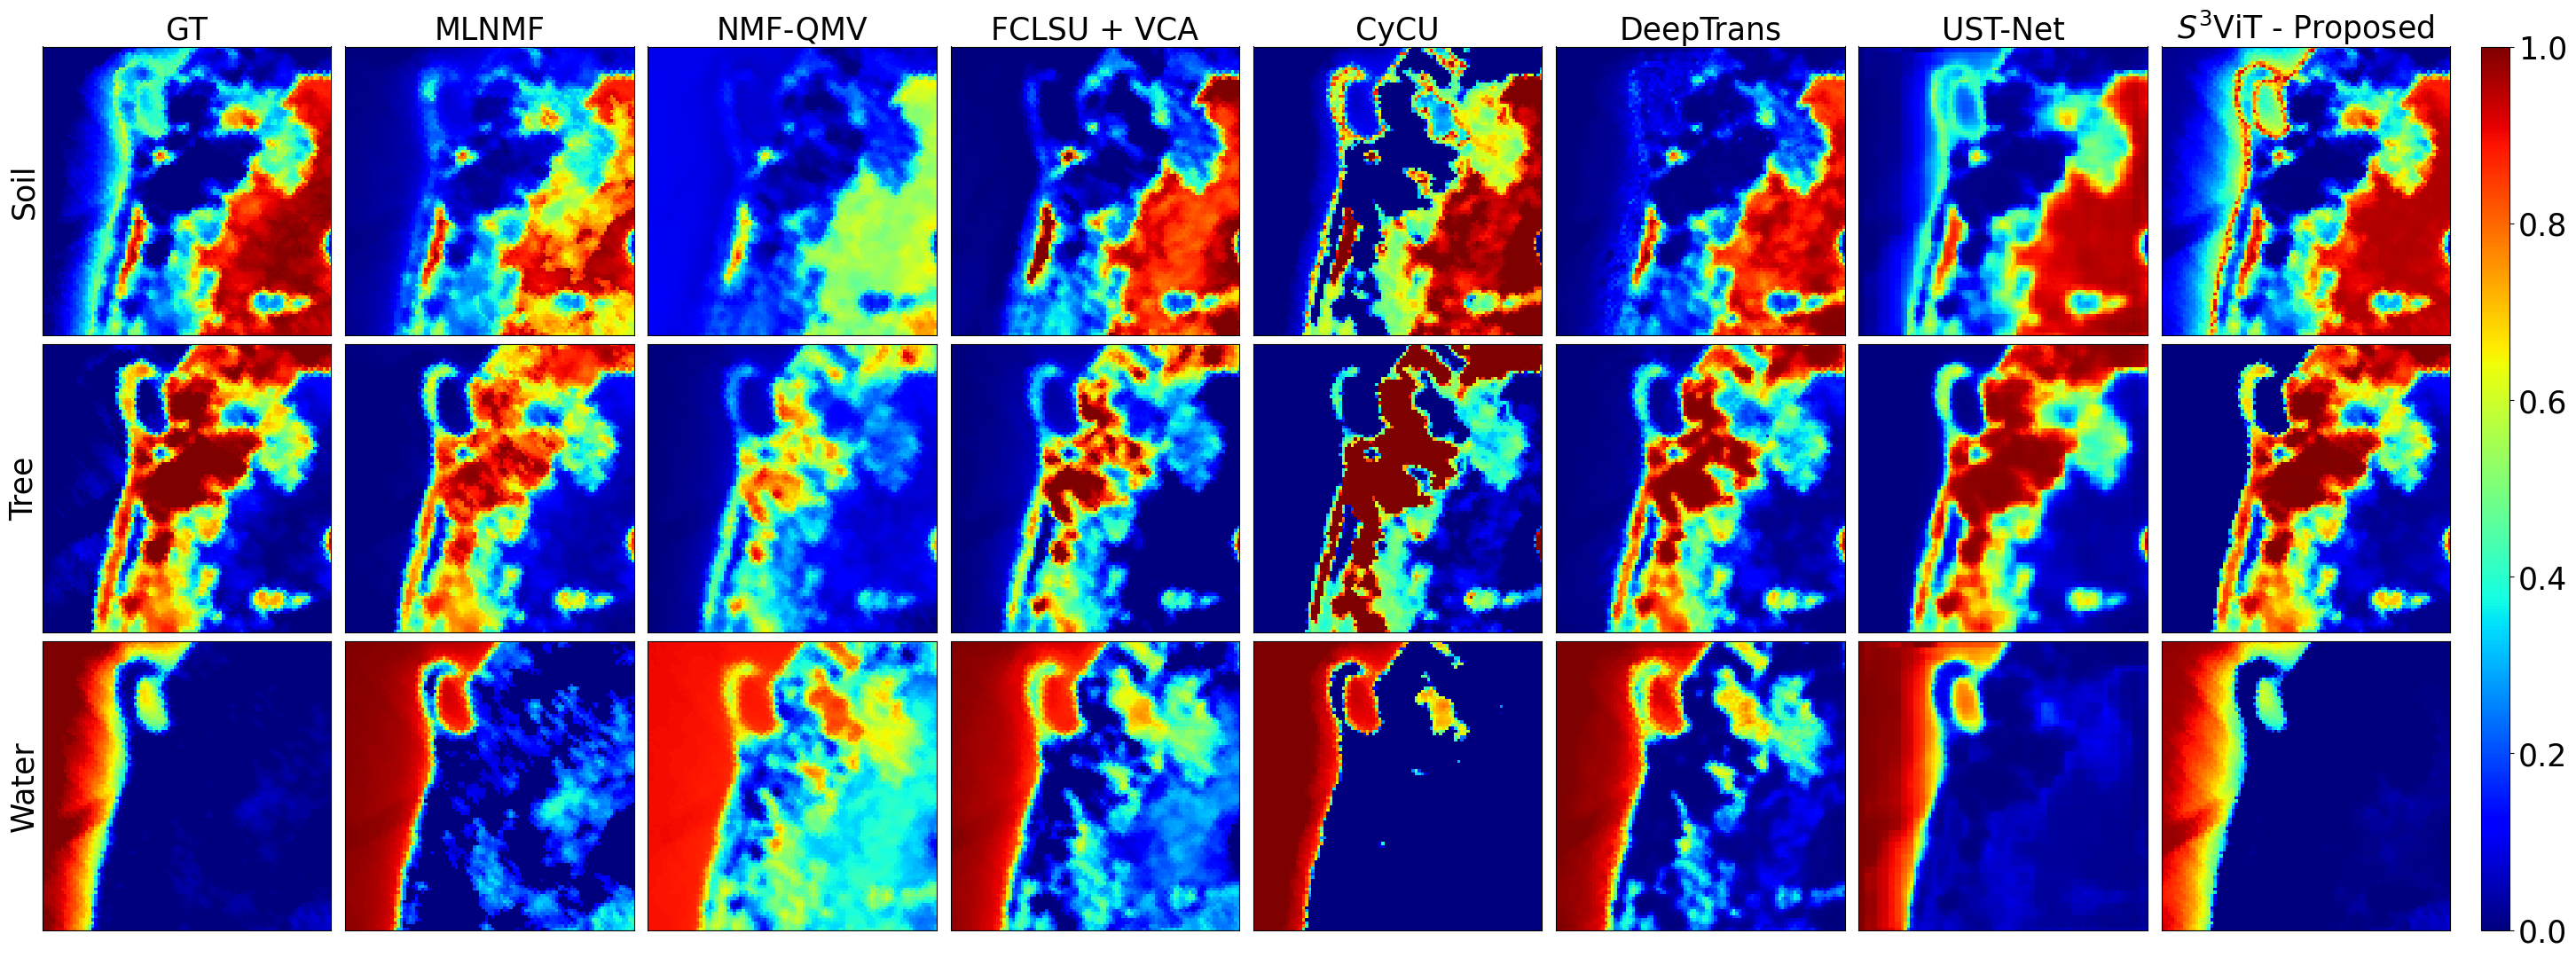

In [39]:
methods = {
    'GT':             maps_GT,
    'MLNMF':          abundance_maps_mlnmf,
    'NMF-QMV':        abundance_maps_nmfqmv,
    'FCLSU + VCA':    abundance_maps_fcls,
    'CyCU':  abundance_maps_cycu,
    'DeepTrans':  abundance_maps_dt,
    'UST-Net':  abundance_maps_ust,
    r'$S^3$ViT - Proposed': abundance_maps_vit
}

row_names = ['Soil', 'Tree', 'Water']
n_rows    = len(row_names)
n_cols    = len(methods)

n_methods = len(methods)
n_endmembers, H, W = next(iter(methods.values())).shape

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(4*n_cols, 4*n_rows),
    gridspec_kw={
        'top':   0.88,
        'wspace': 0.03,   # horizontal space between columns
        'hspace': 0.03    # vertical space between rows
    }
)

# plot maps
for col, (name, maps) in enumerate(methods.items()):
    for row in range(n_rows):
        ax = axes[row, col]
        im = ax.imshow(maps[row], cmap='jet', vmin=0, vmax=1)
        ax.set_xticks([])
        ax.set_yticks([])
        if row == 0:
            ax.set_title(name, fontsize=25)
        if col == 0:
            ax.set_ylabel(
                row_names[row],
                fontsize=25,
                rotation=90,       # ← rotate 90 degrees
                labelpad=15,       # you can tweak this padding
                va='center'
            )

# build a ScalarMappable for the shared colormap
norm = plt.Normalize(vmin=0, vmax=1)
sm   = plt.cm.ScalarMappable(cmap='jet', norm=norm)
sm.set_array([])

# add one tall colorbar on the right
cbar_ax = fig.add_axes([0.91, 0.05, 0.01, 0.83])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
# increase tick label font size
cbar.ax.tick_params(labelsize=25)
# adjust the main grid to make room on the right
fig.subplots_adjust(
    left=0.05, right=0.90, top=0.95, bottom=0.05,
    wspace=0.1, hspace=0.2
)
fig.savefig('abundance_maps_SAMSON_300.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_35644\1957240491.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


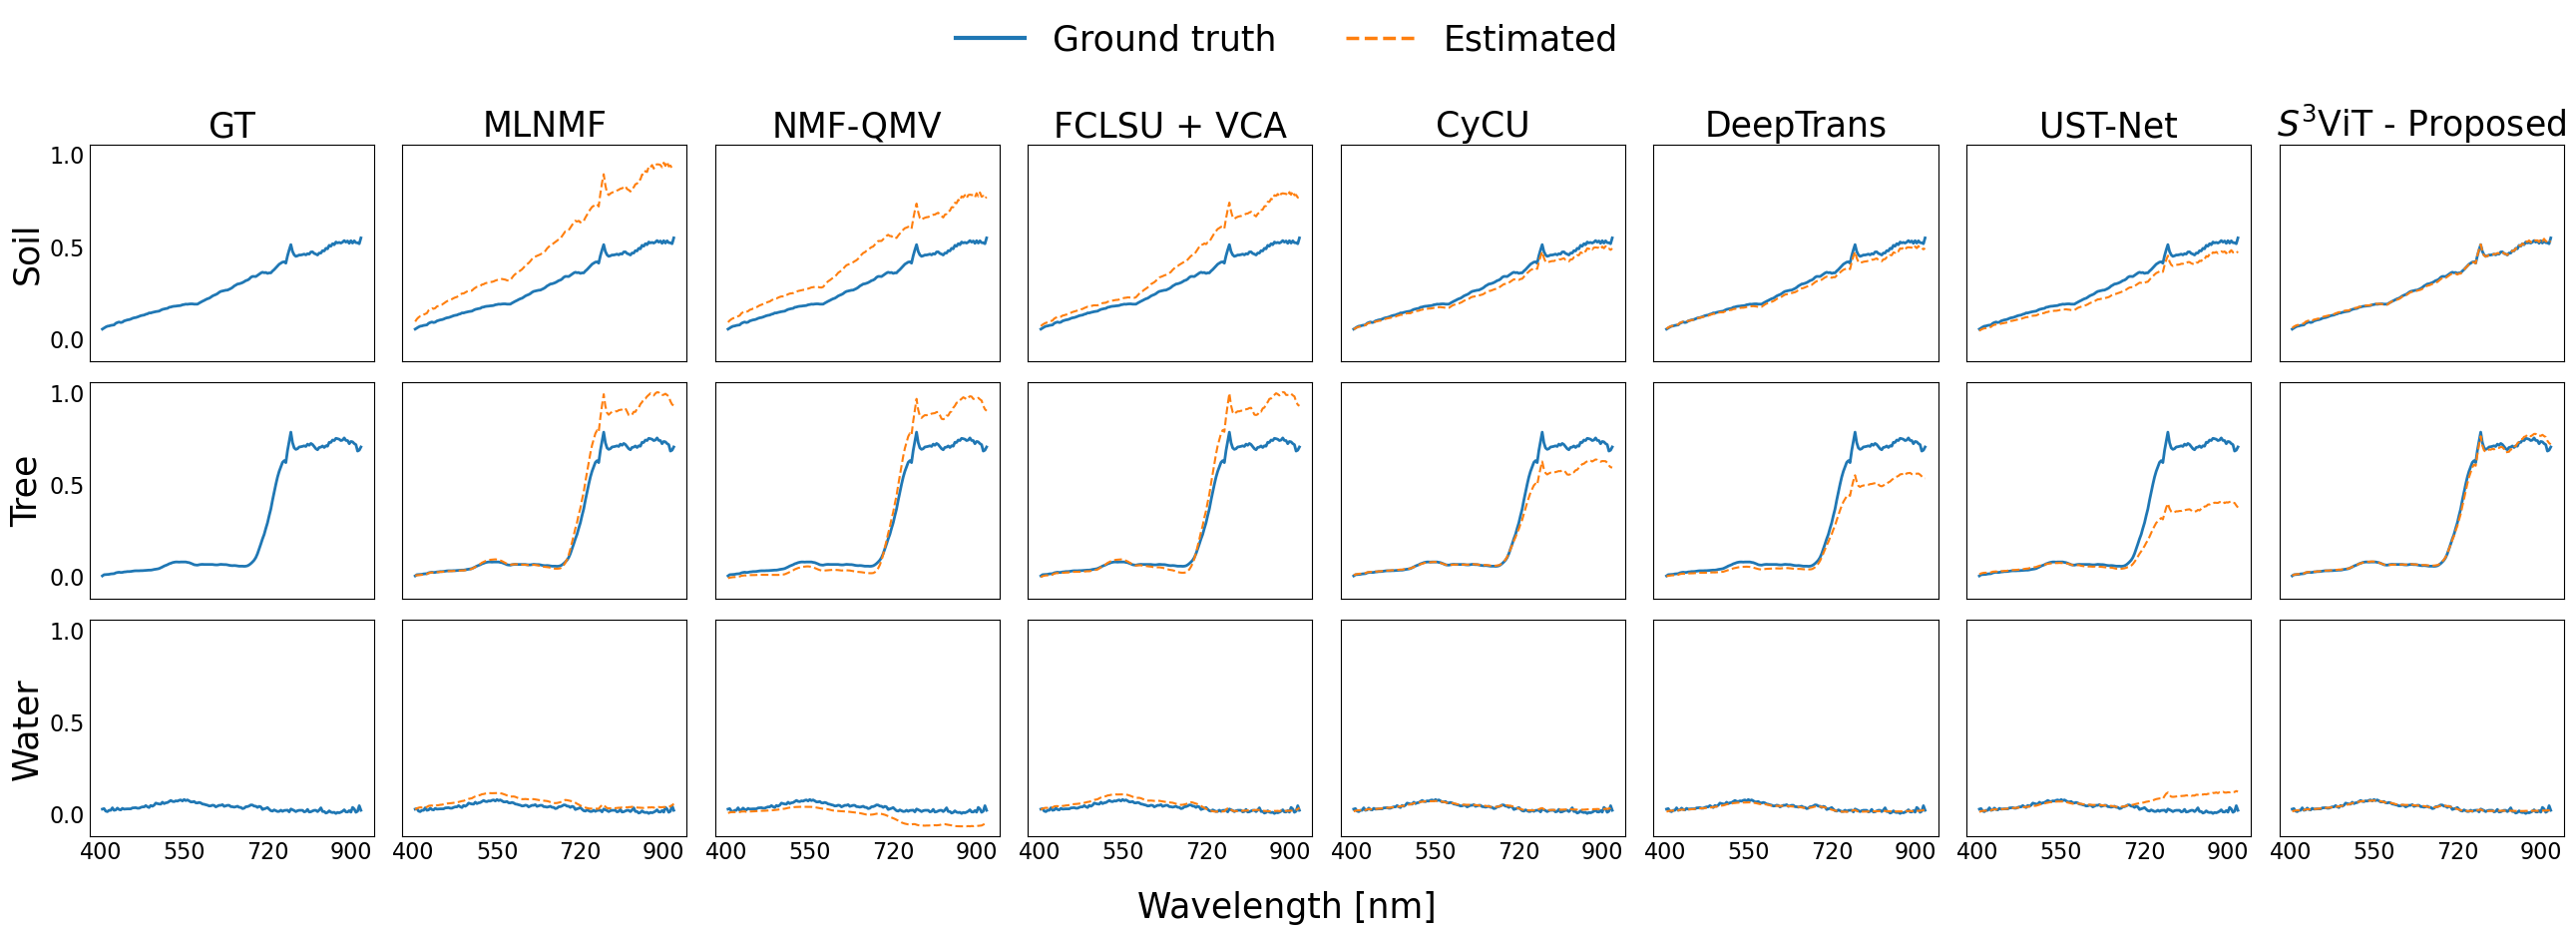

In [40]:
# assume specs, A_output_mlnmf, A_output_nmfqmv, A_output_fclsu, A_output_vit 
# are all currently (bands, endmembers)

# # # reorder FCLSU endmembers if needed
# order = [1,2,0]
# A_output_fclsu = A_output_fclsu[:, order]

# build dict of (endmembers, bands) arrays
methods_specs = {
    'GT':             specs.T,
    'MLNMF':          A_output_mlnmf.T,
    'NMF-QMV':        A_output_nmfqmv.T,
    'FCLSU + VCA':    A_output_fclsu.T,
    'CyCU':  A_output_cycu.T,
    'DeepTrans':  A_output_dt.T,
    'UST-Net':  A_output_ust.T,
    r'$S^3$ViT - Proposed': A_output_vit.T
}

row_names = ['Soil', 'Tree', 'Water']
n_rows    = len(row_names)
n_cols    = len(methods_specs)
endmembers, bands = next(iter(methods_specs.values())).shape
band_idx = np.arange(1, bands+1)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(4*n_cols, 3*n_rows),
    sharex=True, sharey=True,
    gridspec_kw={'wspace':0.1, 'hspace':0.1}
)

for col, (name, spec_arr) in enumerate(methods_specs.items()):
    for row in range(n_rows):
        ax = axes[row, col]

        if name == 'GT':
            ax.plot(band_idx, spec_arr[row], color='C0', lw=2)
        else:
            ax.plot(band_idx, methods_specs['GT'][row],
                    color='C0', lw=2)
            ax.plot(band_idx, spec_arr[row],
                    '--', color='C1', lw=1.5)

        # Titles
        if row == 0:
            ax.set_title(name, fontsize=25)

        # Y‐labels on first column only
        if col == 0:
            ax.set_ylabel(row_names[row], fontsize=25)
            ax.yaxis.set_tick_params(labelleft=True)
        else:
            ax.yaxis.set_tick_params(labelleft=False)

        # X‐labels on bottom row only
        if row == n_rows - 1:
            # set tick positions at the same places you already had
            tick_positions = [0, 50, 100, 150]
            ax.set_xticks(tick_positions)
            # now _only_ replace the labels
            ax.set_xticklabels(['400','550','720','900'], fontsize=16)
        else:
            ax.set_xticks([])

        # no tick‐marks
        ax.tick_params(axis='both', which='both', length=0)
        
        for ax in axes.flatten():
           ax.tick_params(axis='both', labelsize=16)
# Build one global legend (GT vs Estimated)
from matplotlib.lines import Line2D
handles = [
    Line2D([0],[0], color='C0', lw=3),
    Line2D([0],[0], color='C1', lw=2.5, linestyle='--')
]
labels  = ['Ground truth','Estimated']

# Place it below the main suptitle
#fig.suptitle('Endmember Spectral Signatures: Methods vs GT', fontsize=16, y=0.99)
fig.legend(
    handles, labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.05),
    ncol=2,
    frameon=False,
    fontsize=25
)
# add one big shared label
fig.text(0.5, 0.02, 'Wavelength [nm]', ha='center', fontsize=25)

plt.tight_layout()
plt.subplots_adjust(top=0.88)  # make room for title & legend
fig.savefig('endmembers_SAMSON_300.png', dpi=300, bbox_inches='tight')
plt.show()